## The Air Quality Index (AQI)

The Air Quality Index for a specific pollutant is calculated using the formula:

$$
I_{p}
=
\frac{I_{hi}-I_{low}}{BP_{hi}-BP_{low}} * (C_{p}-BP_{low}) + I_{low}
$$

**Where:**

- \\(I_p\\) — calculated AQI for the pollutant.
- \\(C_p\\) — measured concentration of the pollutant.
- \\(BP_{hi}\\) — breakpoint concentration **≥** \\(C_p\\).
- \\(BP_{low}\\) — breakpoint concentration **≤** \\(C_p\\).
- \\(I_{hi}\\) — AQI corresponding to \\(BP_{hi}\\).
- \\(I_{low}\\) — AQI corresponding to \\(BP_{low}\\).

> Note: truncate \\(C_p\\) to the pollutant's required precision before applying the formula.

> ⚠️ For many pollutants, the measured concentration is **truncated to a specific decimal precision** before applying the formula.

---

## ⚙️ How the AQI Works

1. **Measure pollutant concentrations**
   The six key pollutants monitored for AQI are:
   **PM₂.₅, PM₁₀, O₃, CO, SO₂, NO₂**.

2. **Find corresponding breakpoints**
   Using standard AQI breakpoint tables, identify the range in which the pollutant’s concentration falls.

3. **Apply the AQI formula**
   Compute the individual AQI value for each pollutant using the formula above.

4. **Determine the overall AQI**
   The final AQI reported for a region is:

   > **the highest AQI value among all measured pollutants**
   > because it indicates the worst health risk at that time.

---

## Can AQI Be Calculated Without All Six Pollutants?

Yes.
Each pollutant is **evaluated independently**, and **AQI does not require all six pollutants to be present**.

* If only 3 pollutants are measured → calculate 3 AQIs
* Final AQI = **maximum** of the available pollutant-specific AQIs
* Missing pollutants do **not** prevent AQI reporting—they are simply excluded

This method is confirmed by **IQAir**, **AirNow**, and other environmental agencies.

In [ ]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", None)

In [6]:
server_dir = os.path.dirname(os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd()))))
resources_dir = os.path.join(server_dir, "resources")

data_dir = os.path.join(resources_dir , "data")
file_path = os.path.join(data_dir , "main.csv")
file_path

'e:\\Applications\\projects\\Sehetna Organization\\sehetna\\server\\resources\\data\\main.csv'

In [7]:
df = pd.read_csv(file_path)

In [ ]:
demographic_cols = ['income_level', 'population_millions', 'gdp_per_capita_usd']
geographic_cols = ['country_code', 'country_name', 'region', 'latitude', 'longitude']
date_cols = ['date', 'year', 'month', 'week']
climate_cols = ['temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events']
air_quality_cols = ['pm25_ugm3', 'aqi_pm', 'air_quality_index']
health_indicators_cols = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions', 'healthcare_access_index', 'mental_health_index', 'food_security_index', 'uhs_service_coverage_index']

In [ ]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[ns]


In [ ]:
numerical_cols_df = df.select_dtypes(include=['int64', 'float64'])
numerical_cols_df.dtypes

,0
record_id,int64
year,int64
month,int64
week,int64
latitude,float64
longitude,float64
population_millions,int64
temperature_celsius,float64
temp_anomaly_celsius,float64
precipitation_mm,float64


In [ ]:
df['uhs_service_coverage_index'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 14100 entries, 0 to 14099
Series name: uhs_service_coverage_index
Non-Null Count  Dtype  
--------------  -----  
4807 non-null   float64
dtypes: float64(1)
memory usage: 110.3 KB


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
missing_values_count = df['uhs_service_coverage_index'].isna().sum()
print(f"Number of missing values in 'uhs_service_coverage_index': {missing_values_count}")

Number of missing values in 'uhs_service_coverage_index': 9293


In [ ]:
descriptive_stats = df['uhs_service_coverage_index'].dropna().describe()
print("Descriptive statistics for 'uhs_service_coverage_index' (non-missing values):\n")
print(descriptive_stats)

Descriptive statistics for 'uhs_service_coverage_index' (non-missing values):

count    4807.000000
mean       69.837321
std        13.514367
min        38.000000
25%        60.000000
50%        79.000000
75%        80.000000
max        80.000000
Name: uhs_service_coverage_index, dtype: float64


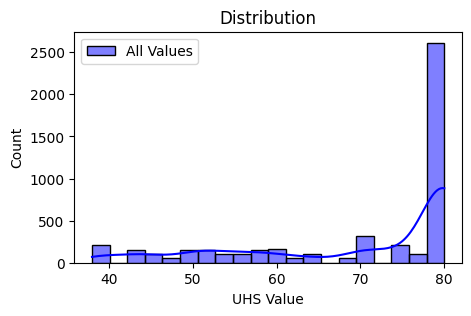

In [ ]:
plt.figure(figsize=(5, 3))

sns.histplot(df['uhs_service_coverage_index'], bins=20, kde=True, color='blue', label='All Values', alpha=0.5)
plt.title('Distribution')
plt.xlabel('UHS Value')
plt.ylabel('Count')
plt.legend()
plt.show()


### Imputation Strategy for 'uhs_service_coverage_index'

Based on the analysis of the descriptive statistics and the visual distribution from the histogram, the `uhs_service_coverage_index` column exhibits a left-skewed distribution. There is a clear concentration of values at the upper end of the scale (75th percentile and max both at 80.0).

Given this non-normal and skewed distribution, simple mean imputation would introduce bias.

However, considering the very high percentage of missing values (9293 out of 14100 entries, approximately 66%), and the potential for this index to be related to other demographic, economic, or health indicators in the dataset, a more sophisticated imputation method is recommended. **K-Nearest Neighbors (KNN) imputation** would be a suitable advanced technique.

## Categorical Feature Encoding

### **Nominal columns**

* Categories **have no ranking**
* Only identity matters (“different or same”)

### **Ordinal columns**

* Categories **have a meaningful natural order or rank**

### **What about `income_level`?**

```
High
Lower-Middle
Upper-Middle
```

This actually has a valid order. So **OrdinalEncoder *can* be correct for this one**.

### **Why One-Hot Encoding not Ordinal Encoding**

* `country_code`, `country_name`, and `region` **do not have rank**
* OrdinalEncoder introduces **artificial order = model confusion**
* One-hot encoding treats categories as **equal and unrelated**

In [ ]:
income_level_order = df['income_level'].unique().tolist()

ordinal_encoder = OrdinalEncoder(categories=[income_level_order], handle_unknown='use_encoded_value', unknown_value=-1)
df['income_level_encoded'] = ordinal_encoder.fit_transform(df[['income_level']])

print(df[['income_level', 'income_level_encoded']].head(2))

# One-hot encode nominal categorical columns
nominal_cols = ['country_code', 'country_name', 'region']
df_encoded_nominal = pd.get_dummies(df[nominal_cols], prefix=nominal_cols, dtype=int)

# Concatenate the new encoded features with the original DataFrame
cat_enc_df = pd.concat([df, df_encoded_nominal], axis=1)

# Drop the original categorical columns
cat_enc_df.drop(columns=nominal_cols + ['income_level'], inplace=True)

cat_enc_df.head()

  income_level  income_level_encoded
0         High                   0.0
1         High                   0.0


,record_id,date,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,heat_wave_days,drought_indicator,flood_indicator,extreme_weather_events,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index,aqi_pm,uhs_service_coverage_index,income_level_encoded,country_code_ARG,country_code_AUS,country_code_BGD,country_code_BRA,country_code_CAN,country_code_CHN,country_code_COL,country_code_DEU,country_code_EGY,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IDN,country_code_IND,country_code_ITA,country_code_JPN,country_code_KEN,country_code_MEX,country_code_NGA,country_code_PAK,country_code_PHL,country_code_THA,country_code_USA,country_code_VNM,country_code_ZAF,country_name_Argentina,country_name_Australia,country_name_Bangladesh,country_name_Brazil,country_name_Canada,country_name_China,country_name_Colombia,country_name_Egypt,country_name_France,country_name_Germany,country_name_India,country_name_Indonesia,country_name_Italy,country_name_Japan,country_name_Kenya,country_name_Mexico,country_name_Nigeria,country_name_Pakistan,country_name_Philippines,country_name_South Africa,country_name_Spain,country_name_Thailand,country_name_United Kingdom,country_name_United States,country_name_Vietnam,region_Africa,region_East Asia,region_Europe,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia
0,1,2015-01-04,2015,1,1,37.09,-95.71,331,4.59,0.76,75.7,0,0,0,0,39.0,82.0,69.4,31.5,6.6,16.2,1.4,77.3,63627.0,71.2,90.2,109.618090,80.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1,2,2015-01-11,2015,1,2,37.09,-95.71,331,3.13,-0.50,97.0,0,0,0,0,17.9,6.0,70.0,26.3,5.2,11.4,0.0,83.6,63627.0,70.6,94.0,67.395437,80.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
2,3,2015-01-18,2015,1,3,37.09,-95.71,331,3.99,-0.14,74.1,0,0,0,0,91.5,137.0,66.9,33.4,1.3,19.5,0.0,84.7,63627.0,63.4,100.0,176.236052,80.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,4,2015-01-25,2015,1,4,37.09,-95.71,331,6.43,-0.06,87.7,0,0,0,0,5.5,-3.0,47.0,35.0,6.0,9.7,9.0,84.3,63627.0,68.1,96.4,30.555556,80.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
4,5,2015-02-01,2015,2,5,37.09,-95.71,331,9.00,0.47,75.8,1,0,0,1,37.1,48.0,61.3,28.3,1.4,22.6,27.3,83.6,63733.0,69.1,100.0,104.939698,80.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0


## Numerical Feature Scaling


In [ ]:
# Identify numerical columns to scale
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Dynamically exclude one-hot encoded columns based on prefixes
exclude_cols = [f"{col}_{val}" for col in nominal_cols for val in df[col].unique()]

# Exclude ID, ordinal encoded, and one-hot encoded columns
exclude_cols.extend(['record_id', 'income_level_encoded', 'heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events'])

# Filter out excluded columns
scaling_cols = [col for col in numerical_cols if col not in exclude_cols]

print(f"Columns identified for scaling: {scaling_cols}")

# Instantiate StandardScaler
temp_scaler = StandardScaler()

# Apply temporary scaling for KNN Imputation
df[scaling_cols] = temp_scaler.fit_transform(df[scaling_cols])

df[scaling_cols].describe()

Columns identified for scaling: ['year', 'month', 'week', 'latitude', 'longitude', 'population_millions', 'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm', 'pm25_ugm3', 'air_quality_index', 'respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions', 'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index', 'food_security_index', 'aqi_pm', 'uhs_service_coverage_index']
Numerical features scaled successfully. Displaying head of updated DataFrame:
       year     month      week  latitude  longitude  population_millions  \
0 -1.575102 -1.589553 -1.689373  0.706766  -1.617942             0.319019   
1 -1.575102 -1.589553 -1.622392  0.706766  -1.617942             0.319019   
2 -1.575102 -1.589553 -1.555411  0.706766  -1.617942             0.319019   
3 -1.575102 -1.589553 -1.488430  0.706766  -1.617942             0.319019   
4 -1.575102 -1.297245 -1.421449  0.706766  -1.617942  

## Perform KNN Imputation for 'uhs_service_coverage_index'

Apply K-Nearest Neighbors (KNN) imputation to fill missing values in the 'uhs_service_coverage_index' column, leveraging other scaled numerical features.


In [ ]:
# Instantiate KNNImputer
# Using n_neighbors=5 as a common starting point
knn_imputer = KNNImputer(n_neighbors=5)
imputed_array = knn_imputer.fit_transform(df[scaling_cols])

df_imputed = temp_scaler.inverse_transform(imputed_array)

# Put values back for other preprocessing steps e.g., outlier removal.
df[scaling_cols] = pd.DataFrame(df_imputed, columns=scaling_cols, index=df.index)

print("KNN imputation completed for selected numerical columns.")

# Verify that there are no more missing values in 'uhs_service_coverage_index'
missing_after_imputation = df['uhs_service_coverage_index'].isna().sum()
print(f"Number of missing values in 'uhs_service_coverage_index' after KNN imputation: {missing_after_imputation}")

print("Descriptive statistics for 'uhs_service_coverage_index' after imputation:")
print(df['uhs_service_coverage_index'].describe())

KNN imputation completed for selected numerical columns.
Number of missing values in 'uhs_service_coverage_index' after KNN imputation: 0
Descriptive statistics for 'uhs_service_coverage_index' after imputation:
count    14100.000000
mean        69.872794
std         12.681105
min         38.000000
25%         57.200000
50%         78.200000
75%         80.000000
max         80.000000
Name: uhs_service_coverage_index, dtype: float64


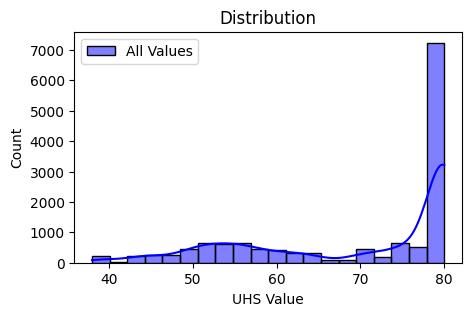

In [ ]:
plt.figure(figsize=(5, 3))

sns.histplot(df['uhs_service_coverage_index'], bins=20, kde=True, color='blue', label='All Values', alpha=0.5)
plt.title('Distribution')
plt.xlabel('UHS Value')
plt.ylabel('Count')
plt.legend()
plt.show()

## Outlier Detection and Treatment

Identify and address outliers within climate and health indicator columns. This may involve statistical methods (e.g., IQR), visualization, and then deciding on treatment strategies like capping, transformation, or removal, with careful consideration of data integrity.


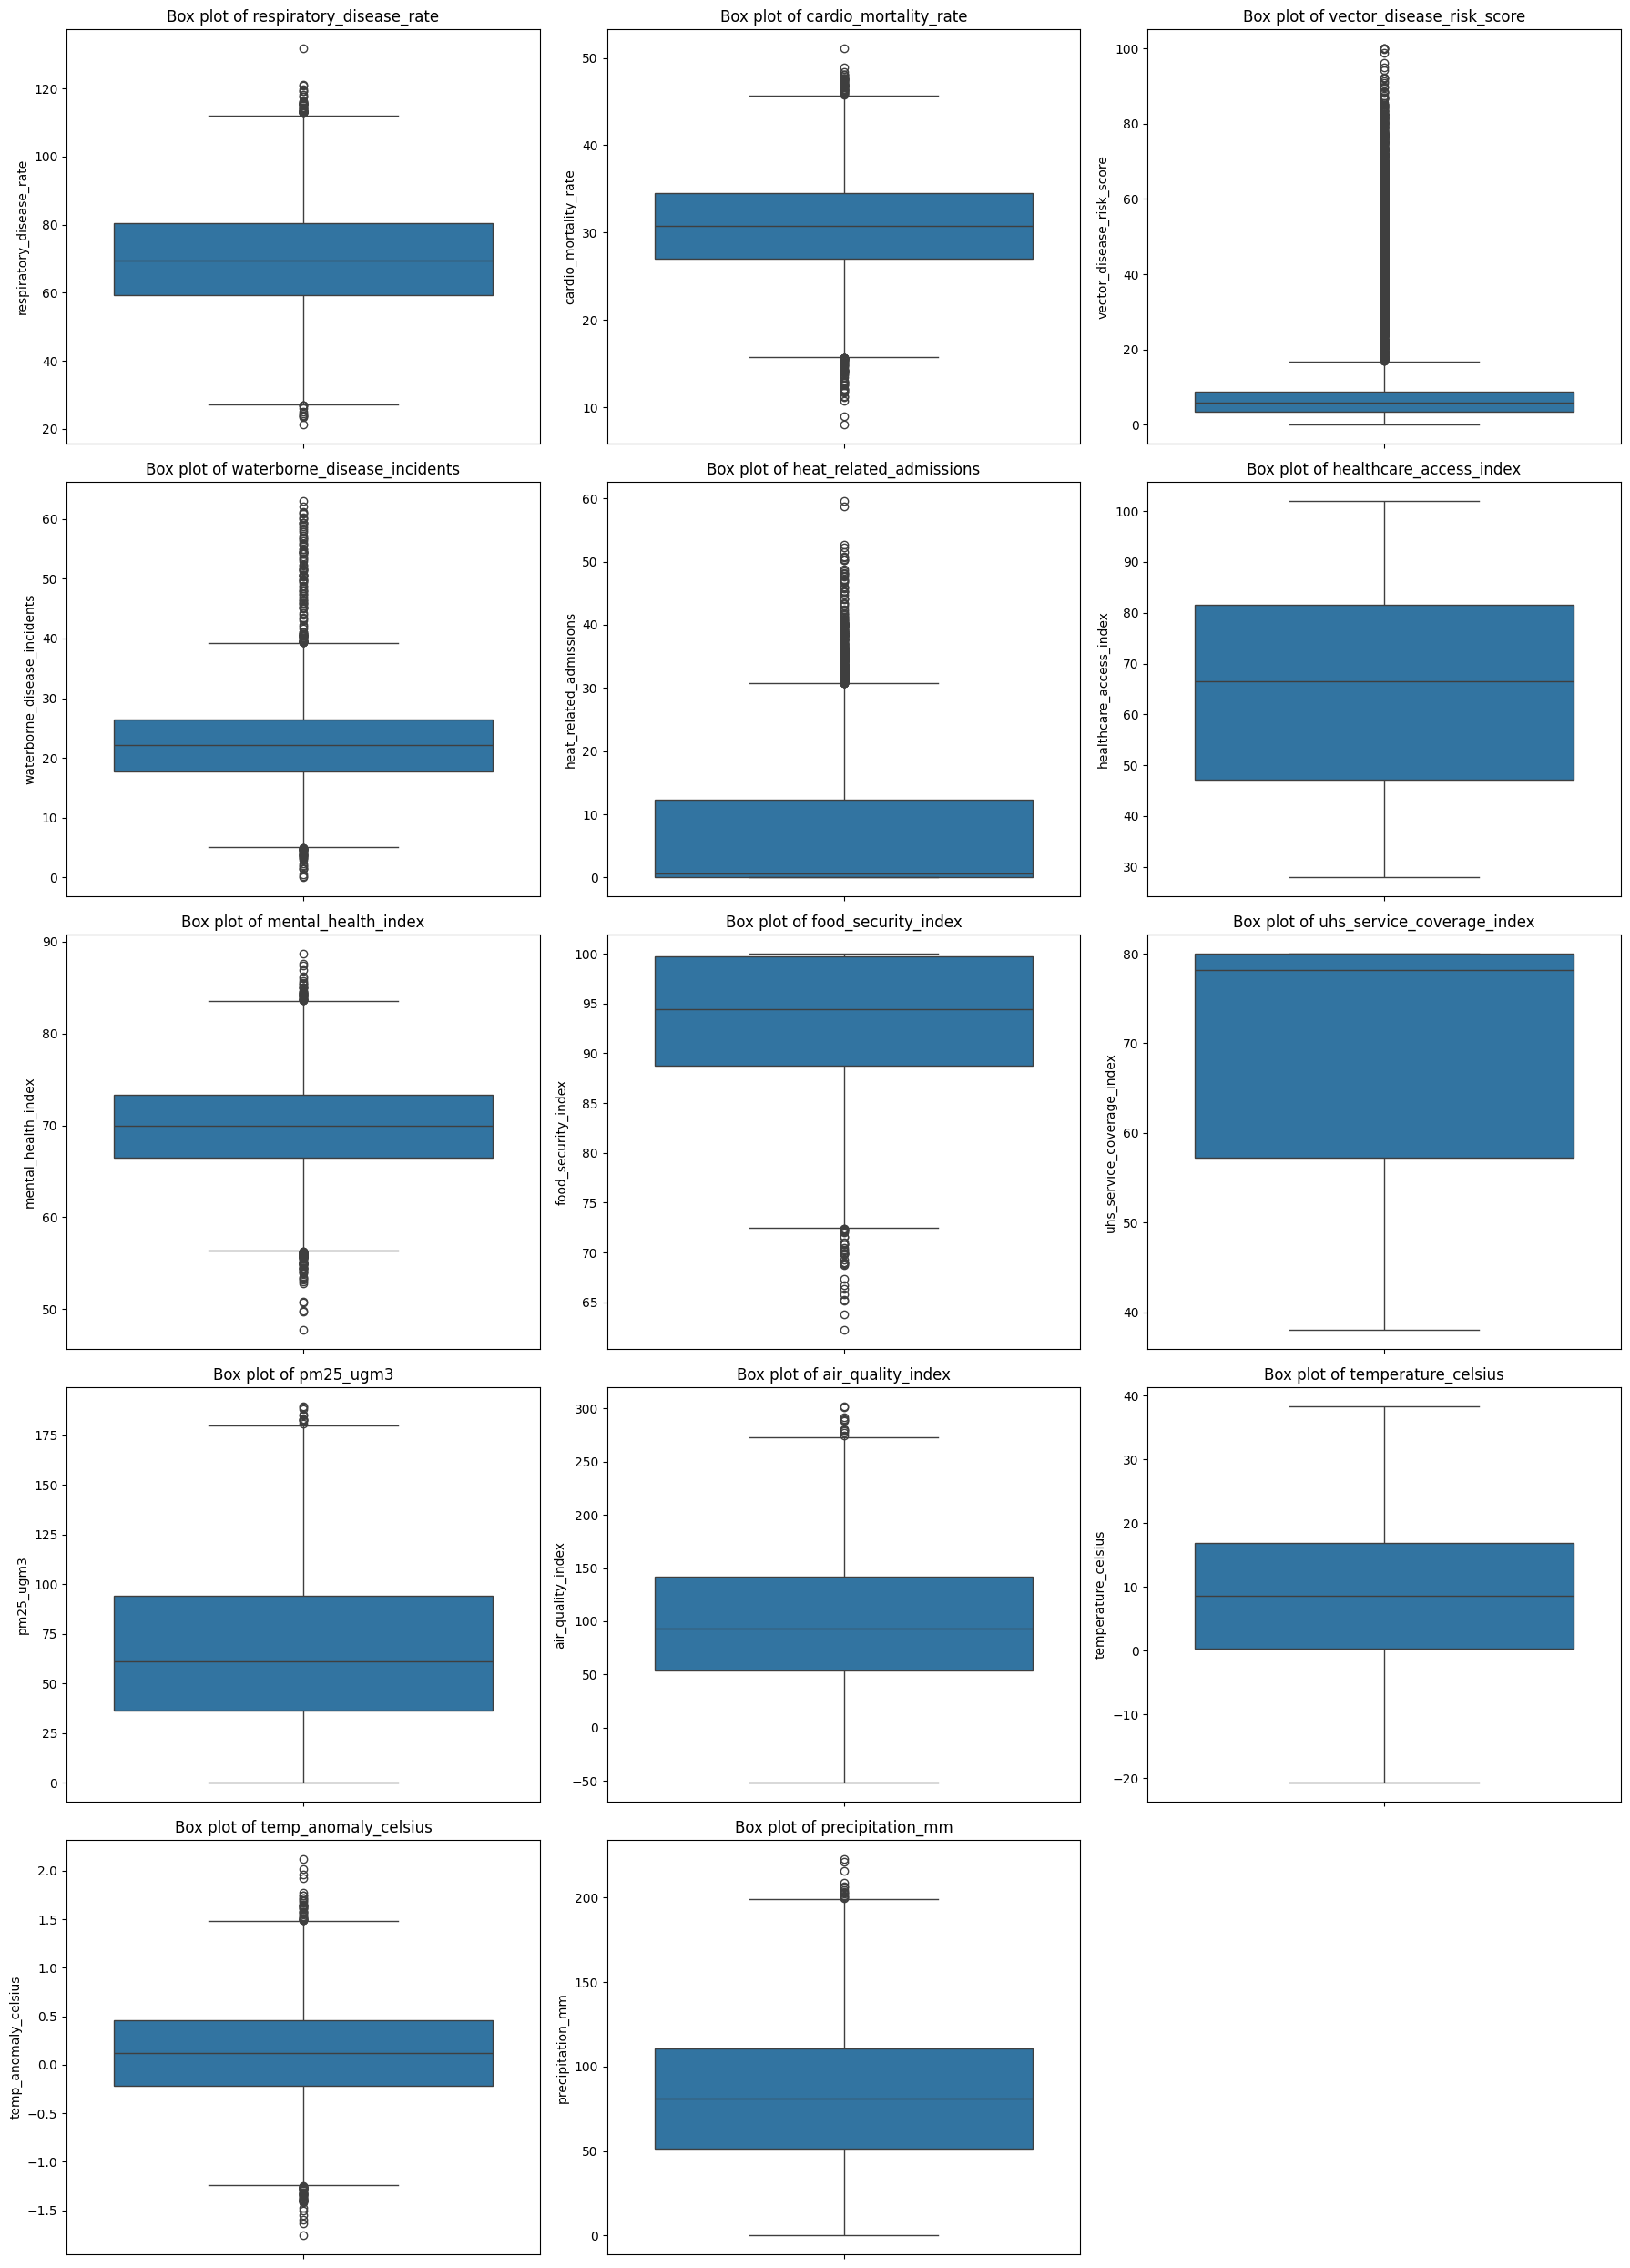

In [ ]:
outlier_cols = [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score',
    'waterborne_disease_incidents', 'heat_related_admissions', 'healthcare_access_index',
    'mental_health_index', 'food_security_index', 'pm25_ugm3', 'air_quality_index',
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm'
]

n_cols = 3
n_rows = math.ceil(len(outlier_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col}')
    axes[i].set_ylabel(col)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
def detect_and_cap_outliers(df, cols, multiplier=1.5, cap=True, show_examples=5, _print=False):
    results = {}

    for col in cols:
        series = df[col].dropna()

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        # Detect outliers
        outliers = df[(df[col] < lower) | (df[col] > upper)]

        if _print:
          print("=" * 70)
          print(f"Outlier Summary for **{col}**")
          print("-" * 70)
          print(f"Q1: {Q1:.3f}")
          print(f"Q3: {Q3:.3f}")
          print(f"IQR: {IQR:.3f}")
          print(f"Lower Bound: {lower:.3f}")
          print(f"Upper Bound: {upper:.3f}")
          print(f"Outlier Count: {len(outliers)}\n")

        if len(outliers) > 0:
          if _print:
            print(f"First {show_examples} outliers:")
            print(outliers[[col]].head(show_examples))
        else:
          if _print:
            print("No outliers detected.")
          continue

        # Store results
        results[col] = {
            "Q1": Q1, "Q3": Q3, "IQR": IQR,
            "lower_bound": lower, "upper_bound": upper,
            "num_outliers": len(outliers)
        }

        #  CAP OUTLIERS (WINSORIZATION)
        if cap:
          if _print:
            print("\nApplying capping...")

          df[col] = df[col].clip(lower=lower, upper=upper)
          if _print:
            print(f"✔ Outliers in '{col}' have been capped.")

          rem = df[(df[col] < lower) | (df[col] > upper)]
          if _print:
            print(f"Remaining outliers after capping: {len(rem)}")

            # Show updated descriptive statistics
            print("\nUpdated Stats:")
            print(df[col].describe())

    return df, results

### Outlier Treatment Strategy

Some columns exhibit outliers, as identified by the box plot and IQR method, and considering the data has already been scaled using `StandardScaler` (which is sensitive to outliers), a capping strategy would be appropriate.

**Strategy: Capping**

-   **Method**: Outliers will be capped at the calculated upper and lower bounds (Q1 - 1.5 * IQR and Q3 + 1.5 * IQR). Any value below the lower bound will be replaced with the lower bound, and any value above the upper bound will be replaced with the upper bound.

In [ ]:
df, _ = detect_and_cap_outliers(df, outlier_cols)

## Perform Scaling

In [ ]:
scaler = StandardScaler()
df[scaling_cols] = scaler.fit_transform(df[scaling_cols])

In [ ]:
df.head(20)

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,heat_wave_days,drought_indicator,flood_indicator,extreme_weather_events,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index,aqi_pm,uhs_service_coverage_index,income_level_encoded
0,1,USA,United States,North America,High,2015-01-04,-1.575102,-1.589553,-1.689373,0.706766,-1.617942,0.319019,-0.355826,1.262218,-0.133499,0,0,0,0,-0.702701,-0.283222,-0.040523,0.132270,-0.320559,-0.903792,-0.577051,0.681553,1.416577,0.263711,-0.491749,-0.576990,0.798634,0.0
1,2,USA,United States,North America,High,2015-01-11,-1.575102,-1.589553,-1.622392,0.706766,-1.617942,0.319019,-0.485149,-1.226193,0.388304,0,0,0,0,-1.256490,-1.568282,-0.001108,-0.795434,-0.402211,-1.630098,-0.724451,1.027147,1.416577,0.144327,0.111862,-1.379578,0.798634,0.0
2,3,USA,United States,North America,High,2015-01-18,-1.575102,-1.589553,-1.555411,0.706766,-1.617942,0.319019,-0.408973,-0.515218,-0.172696,0,0,0,0,0.675209,0.646756,-0.204751,0.471239,-0.629670,-0.404456,-0.724451,1.087489,1.416577,-1.288279,1.064932,0.689314,0.798634,0.0
3,4,USA,United States,North America,High,2015-01-25,-1.575102,-1.589553,-1.488430,0.706766,-1.617942,0.319019,-0.192843,-0.357224,0.160474,0,0,0,0,-1.581939,-1.720460,-1.512008,0.756686,-0.355552,-1.887332,0.223123,1.065547,1.416577,-0.353105,0.493090,-2.079847,0.798634,0.0
4,5,USA,United States,North America,High,2015-02-01,-1.575102,-1.297245,-1.421449,0.706766,-1.617942,0.319019,0.034801,0.689489,-0.131049,1,0,0,1,-0.752569,-0.858117,-0.572622,-0.438625,-0.623837,0.064616,2.149856,1.027147,1.420603,-0.154132,1.064932,-0.665919,0.798634,0.0
5,6,USA,United States,North America,High,2015-02-08,-1.575102,-1.297245,-1.354467,0.706766,-1.617942,0.319019,-0.191958,0.116759,1.711184,0,0,0,0,1.268366,0.984930,0.668943,-0.028294,-0.664663,0.231062,0.528452,0.719952,1.420603,0.044841,0.604281,0.990457,0.798634,0.0
6,7,USA,United States,North America,High,2015-02-15,-1.575102,-1.297245,-1.287486,0.706766,-1.617942,0.319019,-0.154755,0.511745,0.513242,0,0,0,0,-0.967785,-0.807391,0.018599,0.435558,-0.361385,0.488295,0.233651,0.922920,1.420603,-0.273516,1.064932,-0.990013,0.798634,0.0
7,8,USA,United States,North America,High,2015-02-22,-1.575102,-1.297245,-1.220505,0.706766,-1.617942,0.319019,-0.023660,1.025227,0.532841,1,0,0,1,-1.726292,-1.585191,-1.446316,0.453398,-0.332223,-0.676821,1.412854,1.197202,1.420603,-2.084171,0.270707,-2.660660,0.798634,0.0
8,9,USA,United States,North America,High,2015-03-01,-1.575102,-1.004937,-1.153524,0.706766,-1.617942,0.319019,0.086176,-1.877920,0.025736,0,0,0,0,-1.232869,-1.179382,0.675512,-1.045200,-0.361385,-0.586033,0.096779,1.098460,1.424629,1.159090,1.064932,-1.347704,0.798634,0.0
9,10,USA,United States,North America,High,2015-03-08,-1.575102,-1.004937,-1.086543,0.706766,-1.617942,0.319019,-0.031632,1.163472,-0.162897,1,0,0,1,-1.193500,-1.297743,-0.717143,0.310674,-0.687993,-0.510376,0.717967,1.219144,1.424629,0.402993,0.302476,-1.294582,0.798634,0.0


## Feature Engineering and Cyclic Encoding

This includes extracting additional time-based features from the 'date' column (e.g., day of week, quarter), creating interaction terms, and crucially, applying cyclic encoding (sine/cosine transformations) to cyclical features like 'month' and 'week' to represent their periodicity.


In [ ]:
# NEW FEATURES Extract 'day_of_week' and 'quarter'
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['week_sin'] = np.sin(2 * np.pi * df['week'] / 53)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 53)

df.drop(columns=['date', 'month', 'week'], inplace=True)

df[['day_of_week', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos']].head()

Time-based features extracted and cyclically encoded successfully.
Displaying the first few rows with new features:
   day_of_week  quarter  month_sin  month_cos  week_sin  week_cos
0            6        1  -0.739474   0.673186 -0.198940  0.980012
1            6        1  -0.739474   0.673186 -0.191152  0.981560
2            6        1  -0.739474   0.673186 -0.183352  0.983047
3            6        1  -0.739474   0.673186 -0.175540  0.984472
4            6        1  -0.628199   0.778053 -0.167717  0.985835


## Pipeline Construction for Reproducibility

Assemble all the defined preprocessing steps into a Pipeline. This will ensure that all transformations are applied consistently and reproducibly.


In [8]:
# Custom transformer for date feature engineering
class DateFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        X_copy = X_copy.drop(columns=['date', 'month', 'week'])

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            raise ValueError("input_features must be provided to get_feature_names_out for DateFeatureEngineer.")

        original_cols_kept = [col for col in input_features if col not in ['date', 'month', 'week']]
        new_engineered_cols = ['day_of_week', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos']
        return np.array(original_cols_kept + new_engineered_cols)

# Custom transformer for outlier capping
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, multiplier=1.5):
        self.multiplier = multiplier
        self.bounds_ = {}  # store per-column bounds

    def fit(self, X, y=None):
        # Convert X to DataFrame to access column names (works even inside ColumnTransformer)
        X_df = pd.DataFrame(X)

        for col in X_df.columns:
            series = X_df[col].dropna()

            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - self.multiplier * IQR
            upper = Q3 + self.multiplier * IQR

            self.bounds_[col] = (lower, upper)

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)

        for i, col in enumerate(X_df.columns):
            lower, upper = self.bounds_[col]
            X_df.iloc[:, i] = X_df.iloc[:, i].clip(lower=lower, upper=upper)

        return X_df.values

    def get_feature_names_out(self, input_features=None):
        return input_features


In [9]:
data_df = pd.read_csv(file_path)

# Define lists of column names for different preprocessing steps
ordinal_features = ['income_level']

income_level_order = data_df['income_level'].unique().tolist()

nominal_features = ['country_code', 'country_name', 'region']

outlier_cols = [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score',
    'waterborne_disease_incidents', 'heat_related_admissions', 'healthcare_access_index',
    'mental_health_index', 'food_security_index',
    'pm25_ugm3', 'air_quality_index',
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm'
]

uhs_impute_scale_feature = ['uhs_service_coverage_index']

scale_features = ['population_millions', 'aqi_pm', 'gdp_per_capita_usd']

passthrough_features = ['latitude', 'longitude']

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal_encoder', OrdinalEncoder(categories=[income_level_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('onehot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features),

        ('imputer_scaled', Pipeline([
            ('knn', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), uhs_impute_scale_feature),

        ('capper_scaled', Pipeline([
            ('capper', IQRCapper(multiplier=1.5)),
            ('scaler', StandardScaler())
        ]), outlier_cols),

        ('num_scaler', StandardScaler(), scale_features),
        ('pass_through', 'passthrough', passthrough_features),
    ],
    remainder='drop'
)

# Assemble all steps into a final pipeline
pipeline = Pipeline([
    ('date_feature_engineer', DateFeatureEngineer()),
    ('preprocessor', preprocessor)
])

# Fit and transform the raw DataFrame
df_processed_array = pipeline.fit_transform(data_df)

# Dynamically get feature names from the fitted pipeline
all_processed_cols = pipeline.get_feature_names_out(input_features=data_df.columns.tolist()) # Pass input_features here

df_processed = pd.DataFrame(df_processed_array, columns=all_processed_cols, index=data_df.index)

print("Pipeline constructed, fitted, and transformed.")
df_processed.head()


Pipeline constructed, fitted, and transformed.


,ordinal_encoder__income_level,onehot_encoder__country_code_ARG,onehot_encoder__country_code_AUS,onehot_encoder__country_code_BGD,onehot_encoder__country_code_BRA,onehot_encoder__country_code_CAN,onehot_encoder__country_code_CHN,onehot_encoder__country_code_COL,onehot_encoder__country_code_DEU,onehot_encoder__country_code_EGY,onehot_encoder__country_code_ESP,onehot_encoder__country_code_FRA,onehot_encoder__country_code_GBR,onehot_encoder__country_code_IDN,onehot_encoder__country_code_IND,onehot_encoder__country_code_ITA,onehot_encoder__country_code_JPN,onehot_encoder__country_code_KEN,onehot_encoder__country_code_MEX,onehot_encoder__country_code_NGA,onehot_encoder__country_code_PAK,onehot_encoder__country_code_PHL,onehot_encoder__country_code_THA,onehot_encoder__country_code_USA,onehot_encoder__country_code_VNM,onehot_encoder__country_code_ZAF,onehot_encoder__country_name_Argentina,onehot_encoder__country_name_Australia,onehot_encoder__country_name_Bangladesh,onehot_encoder__country_name_Brazil,onehot_encoder__country_name_Canada,onehot_encoder__country_name_China,onehot_encoder__country_name_Colombia,onehot_encoder__country_name_Egypt,onehot_encoder__country_name_France,onehot_encoder__country_name_Germany,onehot_encoder__country_name_India,onehot_encoder__country_name_Indonesia,onehot_encoder__country_name_Italy,onehot_encoder__country_name_Japan,onehot_encoder__country_name_Kenya,onehot_encoder__country_name_Mexico,onehot_encoder__country_name_Nigeria,onehot_encoder__country_name_Pakistan,onehot_encoder__country_name_Philippines,onehot_encoder__country_name_South Africa,onehot_encoder__country_name_Spain,onehot_encoder__country_name_Thailand,onehot_encoder__country_name_United Kingdom,onehot_encoder__country_name_United States,onehot_encoder__country_name_Vietnam,onehot_encoder__region_Africa,onehot_encoder__region_East Asia,onehot_encoder__region_Europe,onehot_encoder__region_North America,onehot_encoder__region_Oceania,onehot_encoder__region_South America,onehot_encoder__region_South Asia,onehot_encoder__region_Southeast Asia,imputer_scaled__uhs_service_coverage_index,capper_scaled__respiratory_disease_rate,capper_scaled__cardio_mortality_rate,capper_scaled__vector_disease_risk_score,capper_scaled__waterborne_disease_incidents,capper_scaled__heat_related_admissions,capper_scaled__healthcare_access_index,capper_scaled__mental_health_index,capper_scaled__food_security_index,capper_scaled__pm25_ugm3,capper_scaled__air_quality_index,capper_scaled__temperature_celsius,capper_scaled__temp_anomaly_celsius,capper_scaled__precipitation_mm,num_scaler__population_millions,num_scaler__aqi_pm,num_scaler__gdp_per_capita_usd,pass_through__latitude,pass_through__longitude
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.288042,-0.040112,0.132602,-0.090827,-0.935837,-0.588985,0.681553,0.264633,-0.495245,-0.702795,-0.283202,-0.355826,1.268328,-0.133389,0.319019,-0.576990,1.416577,37.09,-95.71
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.288042,-0.000608,-0.800887,-0.361263,-1.697360,-0.743266,1.027147,0.144465,0.111143,-1.256720,-1.568937,-0.485149,-1.231951,0.388713,0.319019,-1.379578,1.416577,37.09,-95.71
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.288042,-0.204711,0.473684,-1.114618,-0.412291,-0.743266,1.087489,-1.297557,1.068598,0.675454,0.647263,-0.408973,-0.517585,-0.172608,0.319019,0.689314,1.416577,37.09,-95.71
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [10]:
len(df_processed.columns)

78

In [11]:
", ".join(df_processed.columns.tolist())

'ordinal_encoder__income_level, onehot_encoder__country_code_ARG, onehot_encoder__country_code_AUS, onehot_encoder__country_code_BGD, onehot_encoder__country_code_BRA, onehot_encoder__country_code_CAN, onehot_encoder__country_code_CHN, onehot_encoder__country_code_COL, onehot_encoder__country_code_DEU, onehot_encoder__country_code_EGY, onehot_encoder__country_code_ESP, onehot_encoder__country_code_FRA, onehot_encoder__country_code_GBR, onehot_encoder__country_code_IDN, onehot_encoder__country_code_IND, onehot_encoder__country_code_ITA, onehot_encoder__country_code_JPN, onehot_encoder__country_code_KEN, onehot_encoder__country_code_MEX, onehot_encoder__country_code_NGA, onehot_encoder__country_code_PAK, onehot_encoder__country_code_PHL, onehot_encoder__country_code_THA, onehot_encoder__country_code_USA, onehot_encoder__country_code_VNM, onehot_encoder__country_code_ZAF, onehot_encoder__country_name_Argentina, onehot_encoder__country_name_Australia, onehot_encoder__country_name_Banglades

## Summary:

### Data Analysis Key Findings

*   **Missing Value Handling for `uhs_service_coverage_index`**: The `uhs_service_coverage_index` column initially had a significant number of missing values (9293 out of 14100 entries, approximately 66%). Its non-missing values exhibited a left-skewed distribution (mean: 69.84, median: 79.00). K-Nearest Neighbors (KNN) imputation with `n_neighbors=5` was chosen as the most appropriate method due to the high percentage of missing values and the skewed distribution, and was successfully applied, resulting in 0 missing values for this column.
*   **Categorical Feature Encoding**:
    *   The `income_level` column was successfully ordinal encoded into numerical values (0.0, 1.0, 2.0) representing 'Lower-Middle', 'Upper-Middle', and 'High' respectively, based on an empirically derived order.
    *   Nominal categorical columns (`country_code`, `country_name`, `region`) were successfully one-hot encoded, generating new binary columns for each unique category.
    *   All original categorical columns were removed from the DataFrame.
*   **Numerical Feature Scaling**: A total of 26 numerical columns (e.g., `temperature_celsius`, `pm25_ugm3`, `gdp_per_capita_usd`) were successfully scaled using `StandardScaler`, resulting in features with a mean close to 0 and a standard deviation close to 1. Excluded columns included `record_id`, `income_level_encoded`, and one-hot encoded features.
*   **Outlier Treatment**: Outliers were identified in several numerical columns via box plots and were successfully treated using a capping strategy, ensuring all values fall within the calculated bounds.
*   **Feature Engineering and Cyclic Encoding**:
    *   New time-based features (`day_of_week`, `quarter`) were extracted from the `date` column.
    *   Cyclic features (`month`, `week`) were transformed using sine and cosine functions, creating `month_sin`, `month_cos`, `week_sin`, and `week_cos` to preserve their cyclical nature.
    *   The original `date`, `month`, and `week` columns were subsequently dropped.
*   **Pipeline Construction**: All preprocessing steps, including custom transformers for date feature engineering and outlier capping, were successfully assembled into a robust scikit-learn `Pipeline`. This pipeline correctly handled sequential transformations, column-specific operations via `ColumnTransformer`, and dynamically generated feature names for the final processed DataFrame.

### Next Steps

*   **Model Training and Evaluation**: With a fully preprocessed DataFrame, the next logical step is to proceed with training various machine learning models. The chosen preprocessing techniques (scaling, encoding, imputation, outlier treatment) are well-suited for many supervised learning algorithms, particularly those sensitive to feature scales and distributions.
